In [1]:
# Parameters
name = "H_I-6563"
bins = 4
flux_thresh = 0.001
sigma_thresh = 3.0

In [2]:
import time
start_time=time.time()

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sys
import json
import os
from pathlib import Path
from astropy.io import fits


In [3]:

# Add path to py_modules 
sys.path.append(str(Path().resolve().parents[0] / 'py_modules')) # 1 level up = project root

# Add path to pipeline_config.py
sys.path.append(str(Path().resolve().parents[0]))  # 1 level up = project root

# Import from pipeline_config and py_modules
from pipeline_config import OBSERVATIONS_DIR, MAPS_DIR
from rebin_utils import downsample



# Loading data

In [4]:
# Input FITS files
flux_path    = OBSERVATIONS_DIR / f'linesum-{name}.fits'
radvel_path  = OBSERVATIONS_DIR / f'mean-{name}-patfixx.fits'

# Open files
flux    = fits.open(flux_path)
rad_vel = fits.open(radvel_path)

In [5]:
##IMPORTANT: The information in this cell is replaced in onthers files using the `astrometry_utils.py` file

# Region propertires
dist   = 410   # distance [parsecs]
pix    = 0.2 # spatialscale [arcsec per pixel]

# Observation propertires
seeing = 0.9   # FWHM seeing [arcsec] 

# Conversions
pc = dist * ( 2 * np.pi ) / (360 * 60 * 60) # value in parsecs of each arcsec
s0 = (seeing  * pc) / 2.355 # RMS seeing [parsecs]
pc , s0

(0.0019877360925490972, 0.0007596443665792729)

In [6]:
# Surface brightness data
sb = flux[0].data.astype(float)

# Radial velocity data
vv = rad_vel[0].data.astype(float)

box_size = np.sqrt(sb.shape[0] * sb.shape[1]) * pix * pc


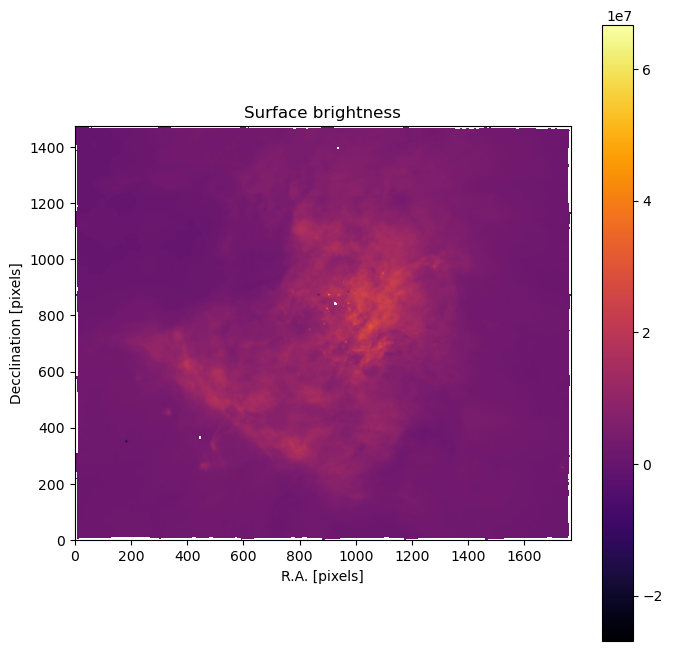

In [7]:
# Surface brightness map

fig, ax = plt.subplots(figsize=(8, 8))

plt.figure(1)
plt.imshow(sb, cmap='inferno')

cbar = plt.colorbar()
#plt.clim(0.001,1)
cbar.set_label(' ', rotation=270, labelpad=15)  

ax.set_xlabel('R.A. [pixels]')
ax.set_ylabel('Decclination [pixels]')
ax.set_title('Surface brightness')


plt.gca().invert_yaxis()

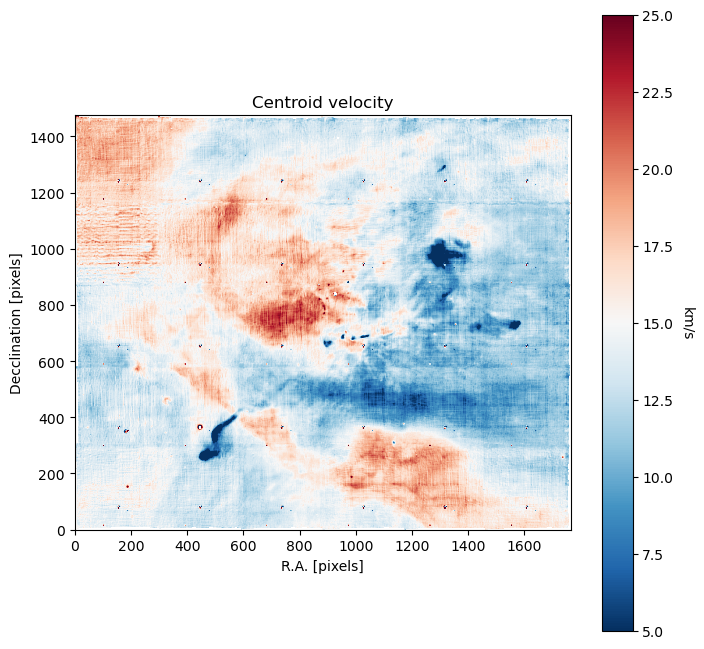

In [8]:
# Velocity map

fig, ax = plt.subplots(figsize=(8, 8))

plt.figure(1)
plt.imshow(vv, cmap='RdBu_r')

cbar = plt.colorbar()
plt.clim(5,25)
cbar.set_label('km/s', rotation=270, labelpad=15)  

ax.set_xlabel('R.A. [pixels]')
ax.set_ylabel('Decclination [pixels]')
ax.set_title('Centroid velocity')

plt.gca().invert_yaxis()

# Downsample

In [9]:
prod_map  = sb * vv
sb_       = pd.notna(sb)
vv_       = pd.notna(vv)
prod_map_ = sb_ * vv_

In [10]:
#bins = 2
mingoods  = [1]*bins

for mingood in zip(mingoods):
 [sb], sb_= downsample([sb], sb_, mingood=mingood)

for mingood in zip(mingoods):
 [prod_map], prod_map_= downsample([prod_map], prod_map_, mingood=mingood)

C:\Users\ZAINTEL2\Dropbox\GitHub\orion_muse\py_modules\rebin_utils.py:107: RuntimeWarning: invalid value encountered in divide
  (


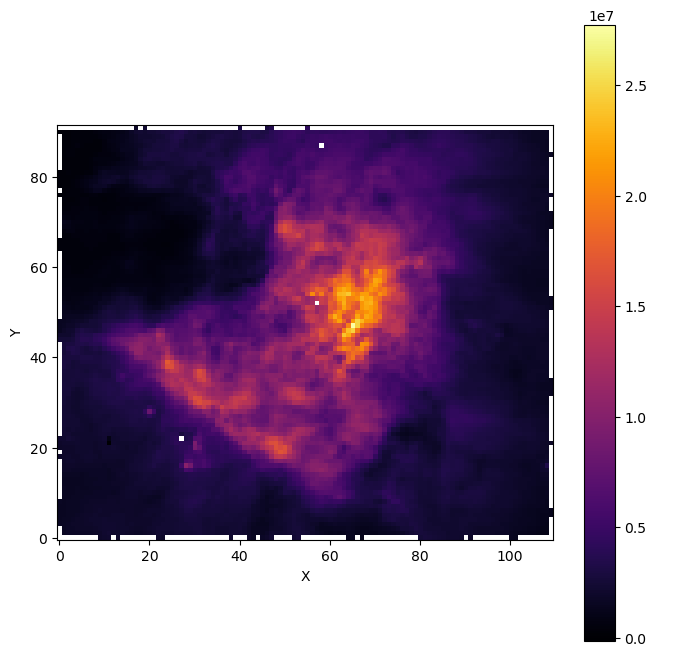

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))

plt.figure(1)
plt.imshow(sb, cmap='inferno')

cbar = plt.colorbar()
#plt.clim(0.001,1)
cbar.set_label(' ', rotation=270, labelpad=15)  

ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.gca().invert_yaxis()

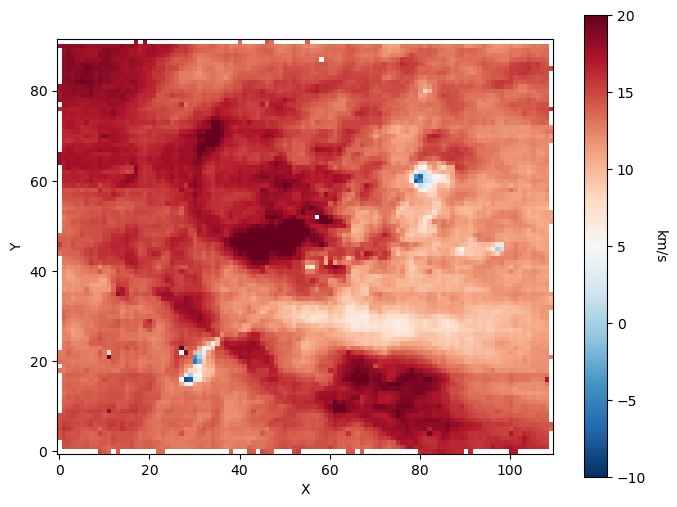

In [12]:
vv = prod_map/sb

fig, ax = plt.subplots(figsize=(8, 6))

plt.figure(1)
plt.imshow(vv, cmap='RdBu_r')

cbar = plt.colorbar()
plt.clim(-10,20)
cbar.set_label('km/s', rotation=270, labelpad=15)  

ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.gca().invert_yaxis()

In [13]:
## Replace spurious values in the arrays
m = ~np.isfinite(sb*vv) | (sb < 0.0)

sb[m] = 0.0
vv[m] = np.nanmean(vv)
sb /= sb.max()

good = (~m) & (sb > 0.001)
#box_size = np.sqrt(sb.shape[0] * sb.shape[1]) * pix * pc

# Mask

In [14]:
# The information in the matrices is converted to a pandas data frame (list form).
# Then the information in the form of list needs to be converted to a matrix again.
# I need to check for other options for performing the mask.

sb_df       = pd.DataFrame(sb)
sb_df       = sb_df.stack().reset_index().rename(columns={'level_0':'X', 'level_1':'Y', 0:'I'})
vv_df       = pd.DataFrame(vv)
data        = vv_df.stack().reset_index().rename(columns={'level_0':'X', 'level_1':'Y', 0:'RV'})
data['I']   = sb_df.I

In [15]:
#sns.pairplot(data, 
#             vars=["I","RV"], 
#             diag_kind='hist',  
#             plot_kws=dict(alpha=0.3, s=10, edgecolor='none'),
#             diag_kws=dict(bins=20),
#            )

In [16]:
mask = (data.I > flux_thresh) & \
(data.RV > data.RV.mean() - sigma_thresh*data.RV.std()) & (data.RV < data.RV.mean() + sigma_thresh*data.RV.std())

In [17]:
#sns.pairplot(data[mask], 
#             vars=["I","RV"], 
#             diag_kind='hist',  
#             plot_kws=dict(alpha=0.3, s=10, edgecolor='none'),
#             diag_kws=dict(bins=20),
#            )

In [18]:
data[mask].describe()

,X,Y,RV,I
count,9742.000000,9742.000000,9742.000000,9742.000000
mean,45.406693,54.447649,14.133560,0.176324
std,26.113283,31.325403,2.609759,0.147091
min,0.000000,0.000000,5.965562,0.010753
25%,23.000000,27.000000,12.402682,0.076123
50%,45.000000,54.000000,14.105259,0.113665
75%,68.000000,82.000000,15.966629,0.247392
max,91.000000,109.000000,22.210875,1.000000


In [19]:
sb_mask = (data[mask].round(2)).pivot(index='X', columns='Y', values='I')
vv_mask = (data[mask].round(2)).pivot(index='X', columns='Y', values='RV')

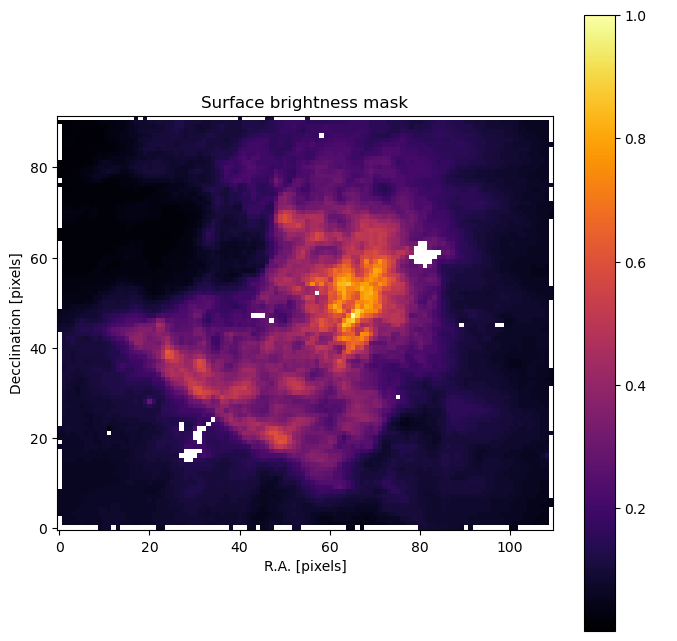

In [20]:
# Surface brightness mask map

fig, ax = plt.subplots(figsize=(8, 8))

plt.figure(1)
plt.imshow(sb_mask, cmap='inferno')

cbar = plt.colorbar()
plt.clim(0.001,1)
cbar.set_label(' ', rotation=270, labelpad=15)  

ax.set_xlabel('R.A. [pixels]')
ax.set_ylabel('Decclination [pixels]')
ax.set_title('Surface brightness mask')

plt.gca().invert_yaxis()

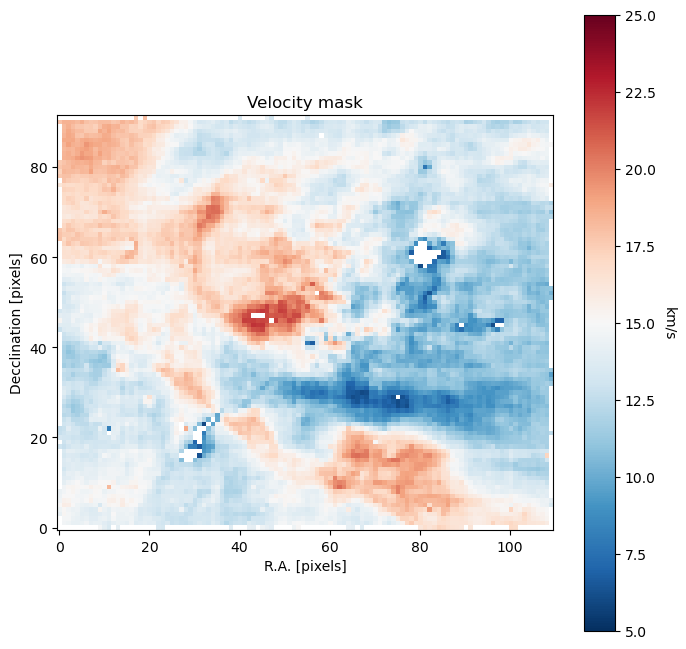

In [21]:
fig, ax = plt.subplots(figsize=(8, 8))


plt.figure(1)
plt.imshow(vv_mask, cmap='RdBu_r')

cbar = plt.colorbar()
plt.clim(5,25)
cbar.set_label('km/s', rotation=270, labelpad=15)  

ax.set_xlabel('R.A. [pixels]')
ax.set_ylabel('Decclination [pixels]')
ax.set_title('Velocity mask')


plt.gca().invert_yaxis()

In [22]:
data_export_matrix = {
       'name': name + "_mask_" +str(2**bins), 
       'pc' : pc,
       's0' : s0,
       'pix' : pix * (2**bins),
       'box_size' : box_size * (2**bins),
       'sb' : sb,
       'vv' : vv,
      }

data_export_matrix

{'name': 'H_I-6563_mask_16',
 'pc': 0.0019877360925490972,
 's0': 0.0007596443665792729,
 'pix': 3.2,
 'box_size': 10.269451075372517,
 'sb': array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.05901023, 0.06234517, ..., 0.03792268, 0.03673711,
         0.        ],
        [0.        , 0.0598841 , 0.06245476, ..., 0.0406782 , 0.03853556,
         0.        ],
        ...,
        [0.        , 0.01206012, 0.01234385, ..., 0.058292  , 0.05848047,
         0.        ],
        [0.01202725, 0.01158204, 0.01294352, ..., 0.05882187, 0.05912741,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ]]),
 'vv': array([[14.09175635, 14.09175635, 14.09175635, ..., 14.09175635,
         14.09175635, 14.09175635],
        [14.09175635, 14.71943176, 14.5437586 , ..., 16.11488233,
         15.8470078 , 14.09175635],
        [14.09175635, 14.84249677, 14.77727411, ..., 15.52

In [23]:
class MyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        else:
            return super(MyEncoder, self).default(obj)


In [24]:
print("--- %s seconds ---" % (time.time()-start_time))

--- 15.28504204750061 seconds ---
